In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc


In [7]:
# Load data
with np.load('/home/server/Projects/data/AKI/preop_trainable/unfiltered_andrew.npz', allow_pickle=True) as data:
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_binary_train = data["y_binary_train"]
    y_binary_test = data["y_binary_test"]

In [8]:
# Define the XGBoost model
xgb_classifier = xgb.XGBClassifier(
    objective="binary:logistic",  # Binary classification (log loss)
    eval_metric="logloss",        # Logarithmic loss for better convergence
    use_label_encoder=False,      # Avoids unnecessary warnings
    n_estimators=1000,             # Number of boosting rounds
    learning_rate=0.1,            # Step size shrinkage
    max_depth=6,                  # Limits tree depth for regularization
    subsample=0.8,                # Prevents overfitting
    colsample_bytree=0.8,         # Reduces features per tree to avoid overfitting
    random_state=42
)

In [9]:
# Train the model
xgb_classifier.fit(X_train, y_binary_train)

/home/server/Projects/VitalDB-Dimensionality-Reduction/.venv/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [05:33:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [10]:
# Predict binary labels
y_pred = xgb_classifier.predict(X_test)

# Classification Metrics
accuracy = accuracy_score(y_binary_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

cm = confusion_matrix(y_binary_test, y_pred)
print('Confusion Matrix:')
print(cm)

report = classification_report(y_binary_test, y_pred)
print('Classification Report:')
print(report)

Accuracy: 0.93
Confusion Matrix:
[[10718   303]
 [  486   212]]
Classification Report:
              precision    recall  f1-score   support

       False       0.96      0.97      0.96     11021
        True       0.41      0.30      0.35       698

    accuracy                           0.93     11719
   macro avg       0.68      0.64      0.66     11719
weighted avg       0.92      0.93      0.93     11719



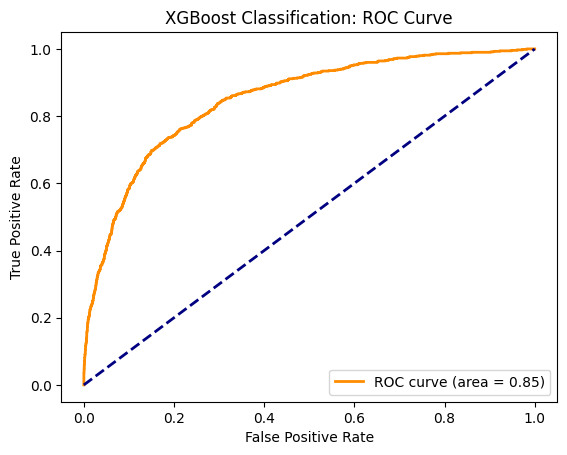

In [11]:
# Predict probabilities for ROC curve
y_prob = xgb_classifier.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_binary_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost Classification: ROC Curve')
plt.legend(loc='lower right')
plt.show()
